# ゼロから作る Deep Learning ❸ 輪読会
## 第3ステージ「高階微分を実現する」 ― ステップ 31 〜 36


### これまでの内容

前回（ステップ 25〜30）は、計算グラフの可視化、テイラー展開、勾配降下法、ニュートン法を通して、高階微分が必要になる理由を確認した。

しかし、これまでの DeZero では `Variable.grad` が NumPy の値だった。そのため、1 階微分の値は求められても、その計算過程には計算グラフが残らず、さらに微分することはできなかった。

今回は逆伝播も `Variable` を使って計算するように改修し、2 階・3 階……の微分を同じ `backward()` で求められるようにする。


### このノートブックの目標

| ステップ | テーマ | 到達点 |
|---|---|---|
| 31 | 高階微分の理論 | 逆伝播の計算グラフを作る考え方を理解する |
| 32 | 高階微分の実装 | `create_graph=True` で微分を再び微分できるようにする |
| 33 | ニュートン法 | 1 階・2 階微分を両方とも自動で求める |
| 34 | `sin` の高階微分 | 周期的に変化する導関数を可視化する |
| 35 | `tanh` の高階微分 | 逆伝播から生まれる複雑なグラフを扱う |
| 36 | ダブルバックプロパゲーション | 微分を含む新しい式をさらに微分する |

> **Table of contents**
> 1. ステップ 31：高階微分（理論編）
> 2. ステップ 32：高階微分（実装編）
> 3. ステップ 33：ニュートン法を使った最適化
> 4. ステップ 34：`sin` 関数の高階微分
> 5. ステップ 35：`tanh` 関数の高階微分
> 6. ステップ 36：高階微分以外の用途


## ライブラリの読み込み

このノートブック単独で実行できるように、必要なライブラリを読み込む。続くセルでは、ステップ 32 の変更点が見える最小構成の DeZero を実装する。


In [1]:
import contextlib
import weakref

import matplotlib.pyplot as plt
import numpy as np

np.random.seed(0)
print("NumPy version:", np.__version__)


NumPy version: 1.26.4


---
# ステップ 31：高階微分（理論編）

## 31.1 微分の計算にも計算グラフを作る

例として $y=x^4$ を考える。1 階微分と 2 階微分は次のとおりである。

$$
y=x^4,\qquad \frac{dy}{dx}=4x^3,\qquad
\frac{d^2y}{dx^2}=12x^2
$$

1 階微分 $4x^3$ を求める計算も、掛け算と累乗からなる普通の計算である。この計算を DeZero の `Variable` で行い、計算グラフを記録すれば、$4x^3$ に対してもう一度 `backward()` を実行できる。

つまり高階微分のために新しい微分アルゴリズムが必要なのではない。**逆伝播を行うときにも、これまで作った自動微分の仕組みを使う**ことがポイントになる。


## 31.2 順伝播のグラフと逆伝播のグラフ

通常の順伝播では、$x$ から $y$ を計算するグラフを作る。

```text
x ── Pow(4) ──> y
```

1 回目の逆伝播を `Variable` の演算として記録すると、勾配 $g_x=4x^3$ に至る別のグラフが作られる。

```text
x ── Pow(3) ──> ... ── Mul ──> gx (= 4x³)
```

この `gx` も `Variable` なので、`gx.backward()` により同じ逆伝播アルゴリズムをもう一度適用できる。その結果が 2 階微分である。


## 31.3 計算グラフの正体はオブジェクト同士の参照

ここでいう「グラフ」は、数式を文字列として保存したものでも、特別な巨大な `Graph` オブジェクトでもない。**`Variable` と `Function` のPythonオブジェクトが互いを参照することで表現される**。

```text
Variable.creator  ──> そのVariableを作ったFunction
Function.inputs   ──> その演算に渡されたVariable
Function.outputs  ──> その演算が作ったVariable
```

たとえば `y = x ** 2` を実行すると、概念的には次の参照が作られる。

```text
x: Variable                   f: Pow                     y: Variable
+---------------+             +---------------+          +---------------+
| data = 2.0    | --inputs--> | c = 2         | --out--> | data = 4.0    |
| creator=None  |             | inputs = [x]  |          | creator = f   |
+---------------+             | outputs = [y] |          +---------------+
                              +---------------+
```

つまり内部では、おおよそ `y.creator = f`、`f.inputs = [x]`、`f.outputs = [y]` という関係になっている。`y.backward()` は `y.creator` から `Pow` へ進み、さらに `Pow.inputs` から `x` へ進む。この参照を出力側から順にたどることが、計算グラフを逆向きにたどるという意味である。


## 31.4 局所的な微分規則を組み合わせる

各 `Function` には、自分の演算を微分する方法が `backward()` としてあらかじめ実装されている。ただし、複雑な関数全体の導関数を登録しているわけではない。登録するのは基本演算ごとの**局所的な微分規則**だけである。

| 基本演算 | `backward()` が使う局所微分 |
|---|---|
| $x_0+x_1$ | 両方へ $g_y$ を渡す |
| $x_0x_1$ | $g_yx_1$, $g_yx_0$ |
| $x^c$ | $g_y c x^{c-1}$ |
| $\sin(x)$ | $g_y\cos(x)$ |

通常の逆伝播は、グラフ上の `Function.backward()` を出力側から順番に呼び、これらを連鎖律で組み合わせる。たとえば $y=(x^2)^3$ なら、`Pow(3)` と `Pow(2)` の局所微分を順に掛け合わせることで $dy/dx$ を求める。

高階微分でも考え方は同じである。違いは、1回目の `backward()` の計算も `Variable` を使って行う点にある。$y=x^4$ の `Pow.backward()` が `gx = 4 * x ** 3 * gy` を実行すると、その `**` と `*` によって新しい `Pow` と `Mul` のオブジェクトが作られる。

```text
元のグラフ:       x ── Pow(4) ──> y

微分計算のグラフ: x ── Pow(3) ──> Mul ──> Mul ──> gx (= 4x^3)
                                      ^       ^
                                      4       gy
```

この新しい `Pow` や `Mul` にも、それぞれの `backward()` がある。そのため `gx.backward()` を呼ぶと、同じ仕組みで新しいグラフを逆向きにたどり、$12x^2$ を求められる。さらにその微分計算も記録すれば、3階、4階と同じ処理を繰り返せる。

> **要点**：基本関数の局所微分を登録し、その微分計算自体も基本関数の組み合わせとしてグラフにする。だから同じ `backward()` を繰り返して高階微分を表現できる。


## 31.5 必要な変更

高階微分を実現する変更は、次の 3 点に整理できる。

1. `Variable.grad` を NumPy 配列ではなく `Variable` として保持する。
2. 各 `Function.backward()` で、入力の `.data` ではなく `Variable` 自体を使う。
3. 逆伝播時に計算グラフを作るかどうかを `create_graph` で選べるようにする。

通常の学習で常に逆伝播グラフを作ると、不要なメモリと計算時間を使ってしまう。そのため、`create_graph=False` をデフォルトにし、高階微分が必要なときだけ `True` にする。

> **ステップ 31 のまとめ**
>
> - 高階微分は「微分の計算」をもう一度微分して求める。
> - そのためには逆伝播も `Variable` の演算として記録する。
> - 記録の有無を `create_graph` で切り替える。


---
# ステップ 32：高階微分（実装編）

## 32.1 `Variable.backward` の改修

以下は高階微分に対応した最小構成の DeZero である。特に `Variable.backward()` の ★ 印に注目する。

- 最初の勾配を `Variable(np.ones_like(...))` にする。
- `create_graph` を引数に追加する。
- `f.backward()` と勾配の加算を `using_config('enable_backprop', create_graph)` の中で行う。

`create_graph=True` のときだけ、逆伝播中の演算が次の微分のための計算グラフとして記録される。


In [2]:
# ===== 高階微分に対応した最小構成の DeZero =====
class Config:
    enable_backprop = True


@contextlib.contextmanager
def using_config(name, value):
    old_value = getattr(Config, name)
    setattr(Config, name, value)
    try:
        yield
    finally:
        setattr(Config, name, old_value)


def no_grad():
    return using_config('enable_backprop', False)


def as_array(x):
    if np.isscalar(x):
        return np.array(x)
    return x


def as_variable(obj):
    if isinstance(obj, Variable):
        return obj
    return Variable(obj)


class Variable:
    __array_priority__ = 200

    def __init__(self, data, name=None):
        if data is not None and not isinstance(data, np.ndarray):
            raise TypeError(f'{type(data)} is not supported')
        self.data = data
        self.name = name
        self.grad = None
        self.creator = None
        self.generation = 0

    def set_creator(self, func):
        self.creator = func
        self.generation = func.generation + 1

    def cleargrad(self):
        self.grad = None

    def backward(self, retain_grad=False, create_graph=False):  # ★ create_graph を追加
        if self.grad is None:
            self.grad = Variable(np.ones_like(self.data))       # ★ grad も Variable

        funcs = []
        seen_set = set()

        def add_func(f):
            if f is not None and f not in seen_set:
                funcs.append(f)
                seen_set.add(f)
                funcs.sort(key=lambda func: func.generation)

        add_func(self.creator)
        while funcs:
            f = funcs.pop()
            gys = [output().grad for output in f.outputs]

            # ★ True のとき、逆伝播中の演算にも計算グラフを作る
            with using_config('enable_backprop', create_graph):
                gxs = f.backward(*gys)
                if not isinstance(gxs, tuple):
                    gxs = (gxs,)

                for x, gx in zip(f.inputs, gxs):
                    if x.grad is None:
                        x.grad = gx
                    else:
                        x.grad = x.grad + gx
                    if x.creator is not None:
                        add_func(x.creator)

            if not retain_grad:
                for y in f.outputs:
                    y().grad = None

    @property
    def shape(self):
        return self.data.shape

    def __repr__(self):
        if self.data is None:
            return 'variable(None)'
        p = str(self.data).replace('\n', '\n' + ' ' * 9)
        return 'variable(' + p + ')'


class Function:
    def __call__(self, *inputs):
        inputs = [as_variable(x) for x in inputs]
        xs = [x.data for x in inputs]
        ys = self.forward(*xs)
        if not isinstance(ys, tuple):
            ys = (ys,)
        outputs = [Variable(as_array(y)) for y in ys]

        if Config.enable_backprop:
            self.generation = max(x.generation for x in inputs)
            for output in outputs:
                output.set_creator(self)
            self.inputs = inputs
            self.outputs = [weakref.ref(output) for output in outputs]

        return outputs if len(outputs) > 1 else outputs[0]

    def forward(self, *xs):
        raise NotImplementedError()

    def backward(self, *gys):
        raise NotImplementedError()


## 32.2 基本演算の `backward` を書き換える

以前の `Mul.backward` は `self.inputs[0].data` のように NumPy 配列を取り出していた。高階微分版では `x0, x1 = self.inputs` とし、`Variable` のまま計算する。

たとえば掛け算 $y=x_0x_1$ の逆伝播は次の式である。

$$
\frac{\partial y}{\partial x_0}=x_1,\qquad
\frac{\partial y}{\partial x_1}=x_0
$$

したがって `gx0 = gy * x1`, `gx1 = gy * x0` と書けば、その計算にも `Mul` のグラフが作られる。累乗や除算も同じ方針で書き換える。


In [3]:
class Add(Function):
    def forward(self, x0, x1):
        return x0 + x1

    def backward(self, gy):
        return gy, gy


class Mul(Function):
    def forward(self, x0, x1):
        return x0 * x1

    def backward(self, gy):
        x0, x1 = self.inputs       # ★ .data を付けず Variable のまま使う
        return gy * x1, gy * x0


class Neg(Function):
    def forward(self, x):
        return -x

    def backward(self, gy):
        return -gy


class Sub(Function):
    def forward(self, x0, x1):
        return x0 - x1

    def backward(self, gy):
        return gy, -gy


class Div(Function):
    def forward(self, x0, x1):
        return x0 / x1

    def backward(self, gy):
        x0, x1 = self.inputs       # ★ Variable の演算で逆伝播する
        return gy / x1, gy * (-x0 / x1 ** 2)


class Pow(Function):
    def __init__(self, c):
        self.c = c

    def forward(self, x):
        return x ** self.c

    def backward(self, gy):
        x, = self.inputs           # ★ Variable のまま使う
        return self.c * x ** (self.c - 1) * gy


def add(x0, x1):
    return Add()(x0, as_array(x1))


def mul(x0, x1):
    return Mul()(x0, as_array(x1))


def neg(x):
    return Neg()(x)


def sub(x0, x1):
    return Sub()(x0, as_array(x1))


def rsub(x0, x1):
    return Sub()(as_array(x1), x0)


def div(x0, x1):
    return Div()(x0, as_array(x1))


def rdiv(x0, x1):
    return Div()(as_array(x1), x0)


def pow(x, c):
    return Pow(c)(x)


Variable.__add__ = add
Variable.__radd__ = add
Variable.__mul__ = mul
Variable.__rmul__ = mul
Variable.__neg__ = neg
Variable.__sub__ = sub
Variable.__rsub__ = rsub
Variable.__truediv__ = div
Variable.__rtruediv__ = rdiv
Variable.__pow__ = pow


## 32.3 2 階微分を求める

$f(x)=x^4-2x^2$ を $x=2$ で微分する。

$$
f'(x)=4x^3-4x,\qquad f''(x)=12x^2-4
$$

したがって期待値は $f'(2)=24$, $f''(2)=44$ である。1 回目の `backward(create_graph=True)` が微分の計算グラフを残し、2 回目の `gx.backward()` がそのグラフを逆伝播する。


In [4]:
def f(x):
    return x ** 4 - 2 * x ** 2


x = Variable(np.array(2.0))
y = f(x)
y.backward(create_graph=True)
gx = x.grad

print("f(2)   =", y.data)
print("f'(2)  =", gx.data, "（期待値 24.0）")
print("grad の型 =", type(gx).__name__)

x.cleargrad()       # 1 階微分と 2 階微分を混ぜない
gx.backward()
print("f''(2) =", x.grad.data, "（期待値 44.0）")


f(2)   = 8.0
f'(2)  = 24.0 （期待値 24.0）
grad の型 = Variable
f''(2) = 44.0 （期待値 44.0）


### 計算グラフを実際に描いて比較する

順伝播で作った $y=f(x)$ のグラフと、`backward(create_graph=True)` が作った 1 階微分 $g_x=f'(x)$ のグラフを並べてみる。

次の描画関数は、出力 `Variable` から `creator` と `inputs` を逆向きにたどり、オレンジ色で変数、水色で関数を表示する。矢印の向きは順伝播の向き（入力 → 関数 → 出力）である。

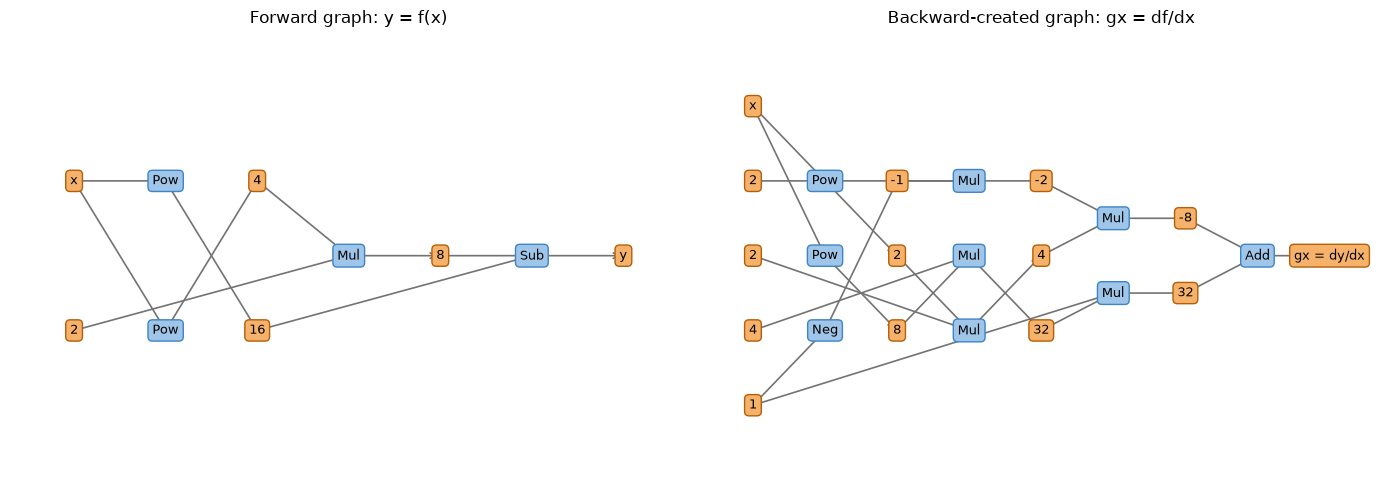

In [5]:
def collect_computation_graph(output):
    """output の計算に必要な Variable、Function、辺を収集する。"""
    variables = {}
    functions = {}
    edges = set()
    stack = [output]

    while stack:
        variable = stack.pop()
        variable_id = f'v{id(variable)}'
        if variable_id in variables:
            continue
        variables[variable_id] = variable

        function = variable.creator
        if function is None:
            continue

        function_id = f'f{id(function)}'
        functions[function_id] = function
        edges.add((function_id, variable_id))
        for input_variable in function.inputs:
            input_id = f'v{id(input_variable)}'
            edges.add((input_id, function_id))
            stack.append(input_variable)

    return variables, functions, edges


def draw_computation_graph(output, ax, title):
    variables, functions, edges = collect_computation_graph(output)
    nodes = {**variables, **functions}

    # Variable は偶数列、Function はその直後の奇数列へ配置する。
    columns = {}
    for node_id, node in variables.items():
        columns.setdefault(2 * node.generation, []).append(node_id)
    for node_id, node in functions.items():
        columns.setdefault(2 * node.generation + 1, []).append(node_id)

    positions = {}
    max_rows = max(len(ids) for ids in columns.values())
    for column, node_ids in sorted(columns.items()):
        node_ids.sort()
        offset = (max_rows - len(node_ids)) / 2
        for row, node_id in enumerate(node_ids):
            positions[node_id] = (column, max_rows - (row + offset))

    for start, end in edges:
        if start not in positions or end not in positions:
            continue
        ax.annotate(
            '', xy=positions[end], xytext=positions[start],
            arrowprops=dict(arrowstyle='->', color='0.45', lw=1.2),
            zorder=1,
        )

    for node_id, node in nodes.items():
        x_pos, y_pos = positions[node_id]
        if node_id.startswith('v'):
            if node.name:
                label = node.name
            elif node.data.size == 1:
                label = f'{float(node.data):.3g}'
            else:
                label = f'shape={node.data.shape}'
            style = dict(boxstyle='round,pad=0.35', fc='#f6b26b', ec='#b45f06')
        else:
            label = node.__class__.__name__
            style = dict(boxstyle='round,pad=0.35', fc='#9fc5e8', ec='#3d85c6')
        ax.text(x_pos, y_pos, label, ha='center', va='center',
                fontsize=9, bbox=style, zorder=2)

    ax.set_title(title)
    ax.set_xlim(-0.7, max(x for x, _ in positions.values()) + 0.7)
    ax.set_ylim(0, max_rows + 1)
    ax.axis('off')


x.name = 'x'
y.name = 'y'
gx.name = 'gx = dy/dx'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
draw_computation_graph(y, axes[0], 'Forward graph: y = f(x)')
draw_computation_graph(gx, axes[1], 'Backward-created graph: gx = df/dx')
plt.tight_layout()
plt.show()

左は元の式 $y=x^4-2x^2$ の計算グラフである。右は同じ `x` から $g_x=4x^3-4x$ を計算するグラフで、`Pow`、`Mul`、`Sub` などの演算として記録されている。この右側の出力 `gx` に `backward()` を適用することで、2 階微分を求められる。

`x.grad` は `Variable` になり、期待どおり 2 階微分まで求められた。2 回目の逆伝播の前に `x.cleargrad()` を呼ぶことも重要である。クリアしないと、すでに入っている 1 階微分へ 2 階微分が加算されてしまう。

なお、最初の `backward()` で `create_graph=False` のままにすると `gx.creator` は `None` となり、再微分用のグラフは残らない。通常の学習ではこちらが省メモリである。


In [6]:
x = Variable(np.array(2.0))
y = f(x)
y.backward()  # create_graph=False がデフォルト

print("gx =", x.grad)
print("gx.creator =", x.grad.creator)


gx = variable(24.0)
gx.creator = None


> **ステップ 32 のまとめ**
>
> - `grad` を `Variable` として保持するようにした。
> - `backward` 内の計算も `Variable` で行うようにした。
> - `create_graph=True` のときだけ逆伝播のグラフを残す。
> - 2 回目の逆伝播前には `cleargrad()` で古い勾配を消す。


---
# ステップ 33：ニュートン法を使った最適化

ステップ 29 では、2 階微分 $f''(x)$ を手計算で用意した。高階微分に対応した今は、1 階微分も 2 階微分も自動で求められる。

ニュートン法の更新式は次のとおりである。

$$
x \leftarrow x - \frac{f'(x)}{f''(x)}
$$

引き続き $f(x)=x^4-2x^2$ を使う。この関数の極小点は $x=\pm1$ であり、初期値 $x=2$ からは $x=1$ へ収束する。


In [7]:
x = Variable(np.array(2.0))
history = []

for i in range(10):
    y = f(x)
    x.cleargrad()
    y.backward(create_graph=True)
    gx = x.grad

    x.cleargrad()
    gx.backward()
    gx2 = x.grad

    history.append((i, float(x.data), float(y.data),
                    float(gx.data), float(gx2.data)))
    x.data -= gx.data / gx2.data

print(" iter |          x |       f(x) |      f'(x) |     f''(x)")
print("-" * 65)
for i, xv, yv, g1, g2 in history:
    print(f"{i:5d} | {xv:10.7f} | {yv:10.7f} | {g1:10.7f} | {g2:10.7f}")
print("\n最終値 x =", x.data)


 iter |          x |       f(x) |      f'(x) |     f''(x)
-----------------------------------------------------------------
    0 |  2.0000000 |  8.0000000 | 24.0000000 | 44.0000000
    1 |  1.4545455 |  0.2447920 |  6.4913599 | 21.3884298
    2 |  1.1510468 | -0.8944343 |  1.4959405 | 11.8989045
    3 |  1.0253259 | -0.9973690 |  0.2103692 |  8.6155191
    4 |  1.0009085 | -0.9999967 |  0.0072775 |  8.0218128
    5 |  1.0000012 | -1.0000000 |  0.0000099 |  8.0000296
    6 |  1.0000000 | -1.0000000 |  0.0000000 |  8.0000000
    7 |  1.0000000 | -1.0000000 |  0.0000000 |  8.0000000
    8 |  1.0000000 | -1.0000000 |  0.0000000 |  8.0000000
    9 |  1.0000000 | -1.0000000 |  0.0000000 |  8.0000000

最終値 x = 1.0


2 階微分の公式をコードに一度も書かず、数回の更新で $x=1$ へ収束した。`create_graph=True` が必要なのは 1 回目の逆伝播だけである。2 階微分をさらに微分しないなら、2 回目はデフォルトの `create_graph=False` でよい。


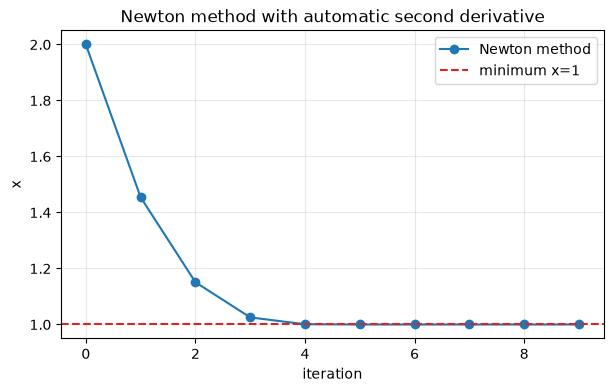

In [8]:
# 収束の様子を可視化する
iters = [row[0] for row in history]
xs = [row[1] for row in history]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(iters, xs, marker='o', label='Newton method')
ax.axhline(1.0, color='tab:red', linestyle='--', label='minimum x=1')
ax.set_xlabel('iteration')
ax.set_ylabel('x')
ax.set_title('Newton method with automatic second derivative')
ax.grid(alpha=0.3)
ax.legend()
plt.show()


> **ステップ 33 のまとめ**
>
> - `y.backward(create_graph=True)` で $f'(x)$ のグラフを作った。
> - `gx.backward()` で $f''(x)$ を自動計算した。
> - 高階微分により、ニュートン法から手計算の導関数を取り除けた。


---
# ステップ 34：`sin` 関数の高階微分

## 34.1 `sin` と `cos` の実装

`sin` の逆伝播には `cos`、`cos` の逆伝播には `sin` が必要になる。

$$
\frac{d}{dx}\sin x=\cos x,\qquad
\frac{d}{dx}\cos x=-\sin x
$$

ここでも `backward` 内で `x.data` を使わず、`Variable` の `x` をそのまま `sin` / `cos` に渡す。


In [9]:
class Sin(Function):
    def forward(self, x):
        return np.sin(x)

    def backward(self, gy):
        x, = self.inputs
        return gy * cos(x)


class Cos(Function):
    def forward(self, x):
        return np.cos(x)

    def backward(self, gy):
        x, = self.inputs
        return gy * -sin(x)


def sin(x):
    return Sin()(x)


def cos(x):
    return Cos()(x)


## 34.2 1〜3 階微分を繰り返す

`sin` の導関数は 4 回で元に戻る。

$$
\sin x \;\to\; \cos x \;\to\; -\sin x
\;\to\; -\cos x \;\to\; \sin x
$$

各回で `x.grad` を保存し、`cleargrad()` の後にその勾配へ `backward(create_graph=True)` を実行する。


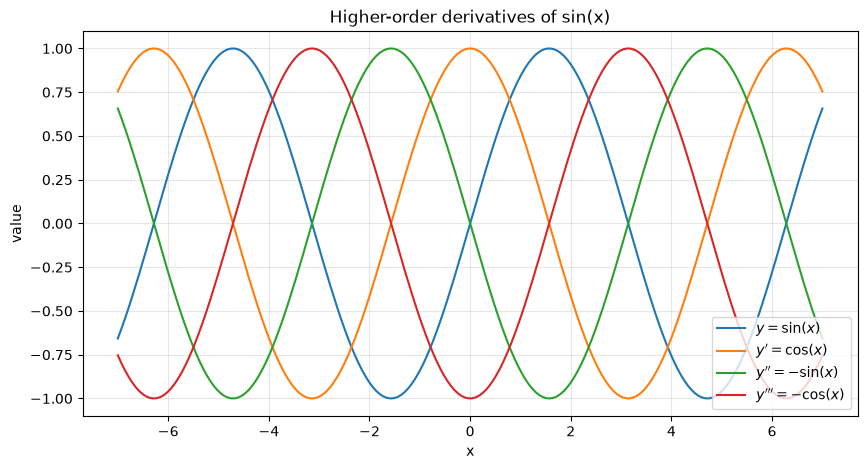

In [10]:
x = Variable(np.linspace(-7, 7, 200))
y = sin(x)
y.backward(create_graph=True)

logs = [y.data.copy(), x.grad.data.copy()]
for _ in range(2):
    gx = x.grad
    x.cleargrad()
    gx.backward(create_graph=True)
    logs.append(x.grad.data.copy())

labels = [r'$y=\sin(x)$', r"$y'=\cos(x)$",
          r"$y''=-\sin(x)$", r"$y'''=-\cos(x)$"]

fig, ax = plt.subplots(figsize=(10, 5))
for values, label in zip(logs, labels):
    ax.plot(x.data, values, label=label)
ax.set_xlabel('x')
ax.set_ylabel('value')
ax.set_title('Higher-order derivatives of sin(x)')
ax.grid(alpha=0.3)
ax.legend(loc='lower right')
plt.show()


曲線は `sin → cos → -sin → -cos` と順番に変化する。高階微分の回数を増やすときも、導関数の公式を追加する必要はない。直前の勾配を新しい出力とみなし、同じ `backward()` を繰り返すだけでよい。

> **ステップ 34 のまとめ**
>
> - `Sin.backward` と `Cos.backward` も `Variable` の演算で実装した。
> - `backward(create_graph=True)` を繰り返して任意階の微分を計算できる。
> - `sin` の導関数が 4 周期で変化することをグラフで確認した。


---
# ステップ 35：`tanh` 関数の高階微分

## 35.1 出力を使った逆伝播

双曲線正接 $y=\tanh(x)$ の導関数は、出力 $y$ を使って簡潔に表せる。

$$
\frac{dy}{dx}=1-y^2
$$

`Function` は出力を弱参照 `self.outputs` に保持しているので、`self.outputs[0]()` で `Variable` として取り出せる。この `y` を使って逆伝播を計算すれば、その演算もグラフに記録できる。


In [11]:
class Tanh(Function):
    def forward(self, x):
        return np.tanh(x)

    def backward(self, gy):
        y = self.outputs[0]()
        return gy * (1 - y * y)


def tanh(x):
    return Tanh()(x)


## 35.2 `tanh` の導関数を可視化する

`tanh` 自体は滑らかな S 字曲線で、1 階微分は原点を中心とする山形になる。2 階・3 階微分では、さらに複雑な形が現れる。逆伝播が作る計算グラフも、微分の階数とともに大きくなる。


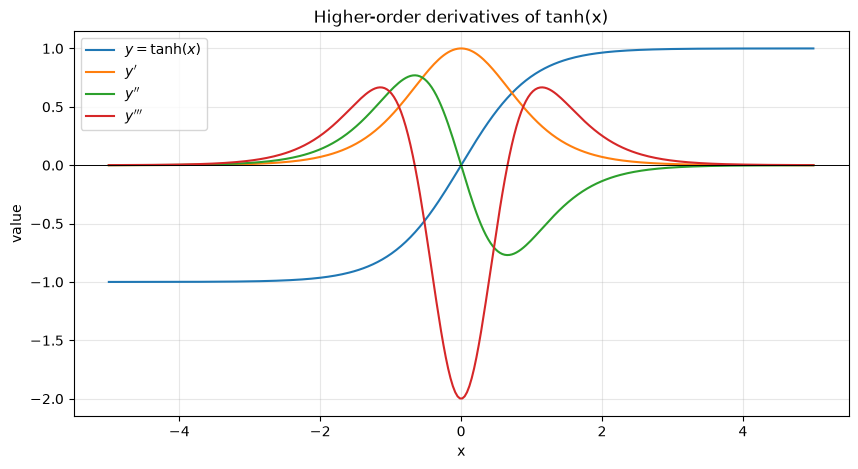

In [12]:
x = Variable(np.linspace(-5, 5, 300))
y = tanh(x)
y.backward(create_graph=True)

tanh_logs = [y.data.copy(), x.grad.data.copy()]
for _ in range(2):
    gx = x.grad
    x.cleargrad()
    gx.backward(create_graph=True)
    tanh_logs.append(x.grad.data.copy())

labels = [r'$y=\tanh(x)$', r"$y'$", r"$y''$", r"$y'''$"]
fig, ax = plt.subplots(figsize=(10, 5))
for values, label in zip(tanh_logs, labels):
    ax.plot(x.data, values, label=label)
ax.axhline(0, color='black', linewidth=0.7)
ax.set_xlabel('x')
ax.set_ylabel('value')
ax.set_title('Higher-order derivatives of tanh(x)')
ax.grid(alpha=0.3)
ax.legend()
plt.show()


### 計算グラフの大きさを確認する

高階微分では「逆伝播が作ったグラフを、さらに逆伝播する」ため、階数が上がるほどグラフは複雑になる。ここでは、2 階微分の結果から辿れる `Variable` と `Function` の数を数えてみる。


In [13]:
def count_graph(output):
    variables = set()
    functions = set()

    def visit_variable(v):
        if id(v) in variables:
            return
        variables.add(id(v))
        if v.creator is not None:
            visit_function(v.creator)

    def visit_function(f):
        if id(f) in functions:
            return
        functions.add(id(f))
        for inp in f.inputs:
            visit_variable(inp)

    visit_variable(output)
    return len(variables), len(functions)


x0 = Variable(np.array(1.0), name='x')
y0 = tanh(x0)
y0.backward(create_graph=True)
gx = x0.grad
x0.cleargrad()
gx.backward(create_graph=True)
gx2 = x0.grad

n_vars, n_funcs = count_graph(gx2)
print("x = 1.0")
print("tanh(x)  =", y0.data)
print("1 階微分 =", gx.data)
print("2 階微分 =", gx2.data)
print(f"2 階微分のグラフ: Variable {n_vars} 個, Function {n_funcs} 個")


x = 1.0
tanh(x)  = 0.7615941559557649
1 階微分 = 0.41997434161402614
2 階微分 = -0.6397000084492246
2 階微分のグラフ: Variable 13 個, Function 9 個


### `tanh` の2階微分グラフ

数だけでなく、実際の2階微分 `gx2` の計算グラフも描いてみる。`Tanh.backward` の $1-y^2$ と、その式をさらに微分するための演算が一つのグラフに現れる。

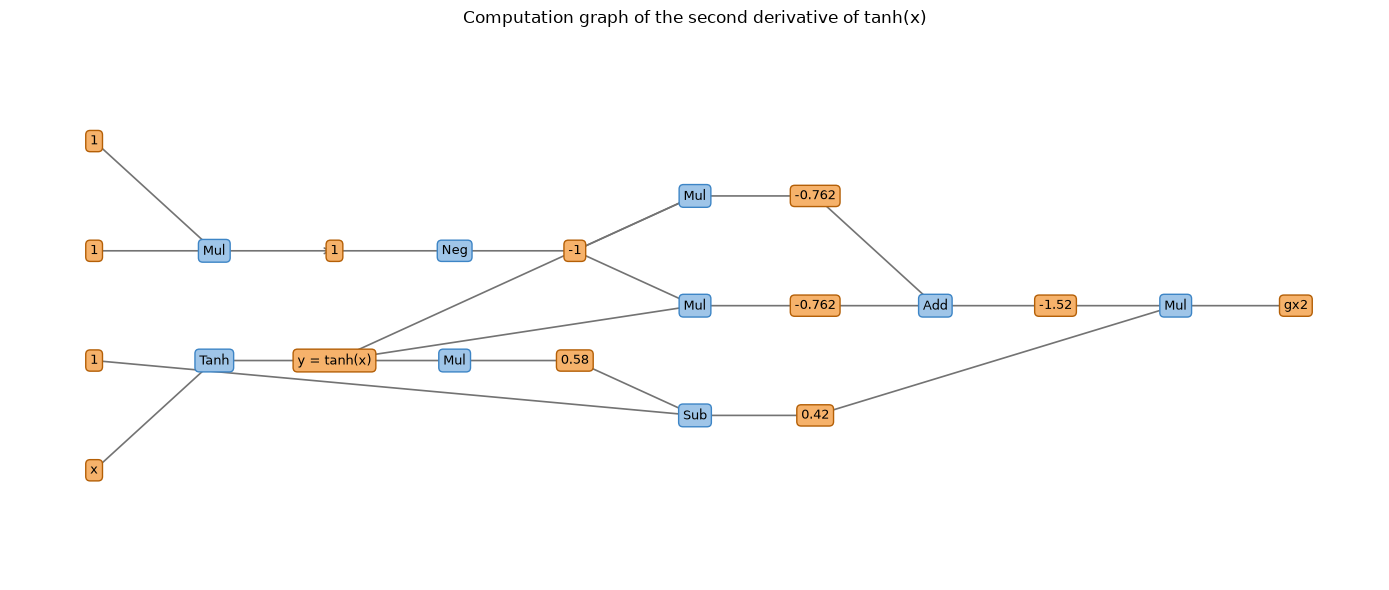

In [14]:
y0.name = 'y = tanh(x)'
gx.name = 'gx'
gx2.name = 'gx2'

fig, ax = plt.subplots(figsize=(14, 6))
draw_computation_graph(gx2, ax, 'Computation graph of the second derivative of tanh(x)')
plt.tight_layout()
plt.show()

`tanh` の `backward` は出力 $y$ を再利用するため、2 階微分のグラフには元の順伝播と 1 回目の逆伝播の演算が組み合わさる。このような複雑な式でも、DeZero はグラフを自動的に辿る。

> **ステップ 35 のまとめ**
>
> - `Tanh.backward` は出力 `y` を `Variable` として使う。
> - 高階微分でも、局所的な逆伝播の式を組み合わせる考え方は変わらない。
> - 微分の階数が上がるほど計算グラフは大きくなる。


---
# ステップ 36：高階微分以外の用途

## 36.1 ダブルバックプロパゲーション

逆伝播の計算グラフを残せると、単に 2 階微分を求めるだけでなく、**勾配を含む新しい計算**を作り、その計算をさらに微分できる。これをダブルバックプロパゲーションと呼ぶ。

次の例を考える。

$$
y=x^2,\qquad g_x=\frac{dy}{dx}=2x
$$

1 階微分 $g_x$ と元の出力 $y$ を使い、新しい変数 $z$ を作る。

$$
z=g_x^3+y=(2x)^3+x^2=8x^3+x^2
$$

したがって、$z$ の $x$ に関する微分は

$$
\frac{dz}{dx}=24x^2+2x
$$

であり、$x=2$ では $100$ になる。


In [15]:
x = Variable(np.array(2.0))
y = x ** 2
y.backward(create_graph=True)
gx = x.grad

x.cleargrad()
z = gx ** 3 + y
z.backward()

print("y       =", y.data)
print("gx=dy/dx=", gx.data)
print("z       =", z.data)
print("dz/dx   =", x.grad.data, "（期待値 100.0）")


y       = 4.0
gx=dy/dx= 4.0
z       = 68.0
dz/dx   = 100.0 （期待値 100.0）


### 勾配と順伝播が合流するグラフ

Step 36 の $z=g_x^3+y$ では、1 回目の逆伝播で作られた `gx` の経路と、元の順伝播で作られた `y` の経路が `Add` で合流する。これがダブルバックプロパゲーションで扱う計算グラフである。

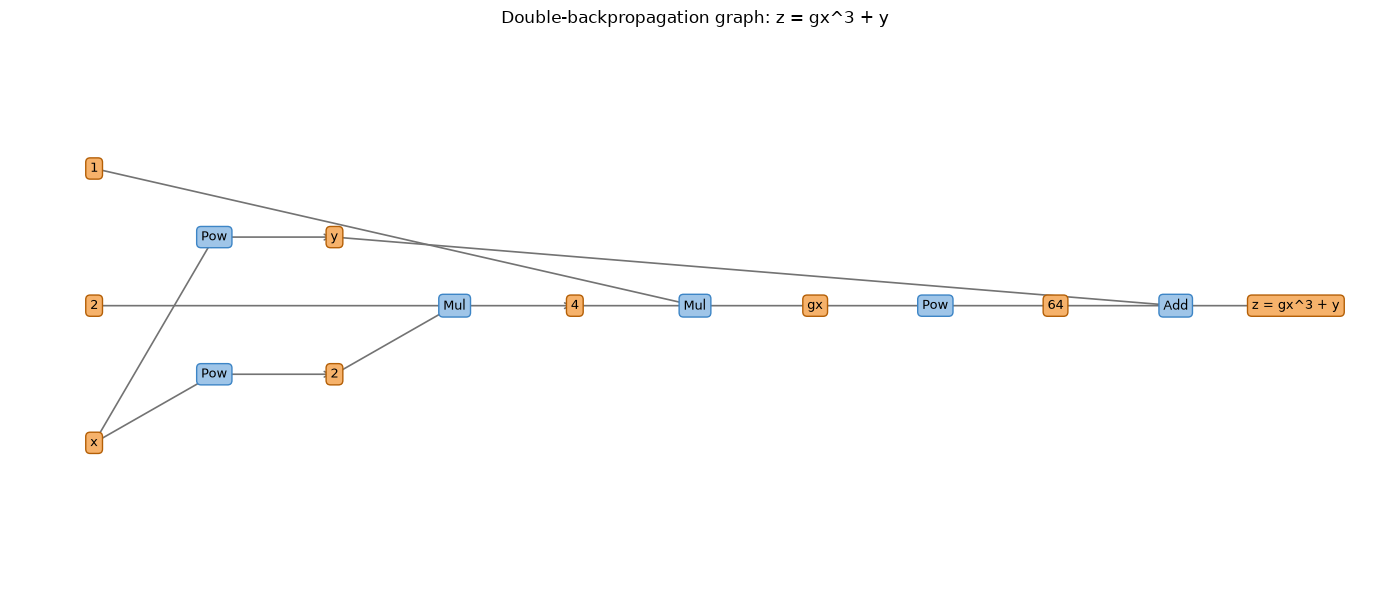

In [16]:
x.name = 'x'
y.name = 'y'
gx.name = 'gx'
z.name = 'z = gx^3 + y'

fig, ax = plt.subplots(figsize=(14, 6))
draw_computation_graph(z, ax, 'Double-backpropagation graph: z = gx^3 + y')
plt.tight_layout()
plt.show()

ここで 2 回目に微分しているのは単なる $y$ ではなく、勾配 $g_x$ を材料に作った新しい目的 $z$ である。`gx` が計算グラフを持つ `Variable` だからこそ、`z.backward()` は $g_x$ を経由する経路と $y$ を経由する経路の両方を正しく辿れる。

この仕組みは、勾配そのものに制約を加える正則化、勾配ペナルティ、メタラーニングなどの基礎になる。


## 36.2 数値微分で検算する

最後に、$z(x)=8x^3+x^2$ を DeZero と独立な中央差分で微分し、ダブルバックプロパゲーションの結果と照合する。


In [17]:
def z_numpy(x):
    return 8 * x ** 3 + x ** 2


h = 1e-4
numerical = (z_numpy(2.0 + h) - z_numpy(2.0 - h)) / (2 * h)
autodiff = float(x.grad.data)

print("自動微分 =", autodiff)
print("数値微分 =", numerical)
print("絶対誤差 =", abs(autodiff - numerical))
assert np.allclose(autodiff, numerical, rtol=1e-6, atol=1e-6)


自動微分 = 100.0
数値微分 = 100.00000008012933
絶対誤差 = 8.012932539713802e-08


> **ステップ 36 のまとめ**
>
> - 勾配 `gx` を新しい計算の一部として利用できる。
> - 元の順伝播と逆伝播からできたグラフをまとめて、もう一度逆伝播できる。
> - ダブルバックプロパゲーションの結果が数値微分と一致した。


---
# まとめ ― 第 3 ステージ後半（ステップ 31〜36）

今回の改修で、DeZero は 1 階微分だけでなく、微分の計算自体を新しい計算グラフとして扱えるようになった。

1. **ステップ 31（理論）**  
   逆伝播を `Variable` の演算として記録し、その結果を再び微分する方針を立てた。
2. **ステップ 32（実装）**  
   `grad` を `Variable` に変更し、`create_graph=True` で逆伝播グラフを作れるようにした。
3. **ステップ 33（ニュートン法）**  
   1 階・2 階微分を自動で求め、手計算の導関数なしで最適化した。
4. **ステップ 34（`sin`）**  
   `backward()` を繰り返し、周期的に変化する高階微分を可視化した。
5. **ステップ 35（`tanh`）**  
   出力を利用する逆伝播でも、高階微分の複雑なグラフを自動構築できた。
6. **ステップ 36（ダブルバックプロパゲーション）**  
   勾配を含む新しい式を作り、その式全体をさらに微分した。

```text
順伝播のグラフを作る
        ↓ backward(create_graph=True)
微分のグラフを作る
        ↓ backward(create_graph=True)
さらに高階の微分へ
```

高階微分のために特別な演算を大量に追加したわけではない。`Variable` と `Function` で計算グラフを作るという、これまでの仕組みを逆伝播にも適用したことが本質である。
